In [196]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random

In [197]:
data_train = pd.read_csv("./data/emotion-labels-train.csv")
data_test = pd.read_csv("./data/emotion-labels-test.csv")
data_val = pd.read_csv("./data/emotion-labels-val.csv")

In [198]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [199]:
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [200]:
emoji_pattern = r"[^\w\s,]"

data['text_clean'] = data['text'].apply(
    lambda x: clean(x, reg=emoji_pattern, reg_replace="")
)


In [201]:
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub("@[^\s]+","", x))

In [202]:
data.head()

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,got back see garydelaney burslem amaz face sti...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear even absolut hilar dont think laugh mu...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,wait week game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,gardinerlov thank much gloria your sweet thoug...
4,I feel so blessed to work with the family that...,joy,feel bless work famili nanni noth love amp app...


<Axes: xlabel='label'>

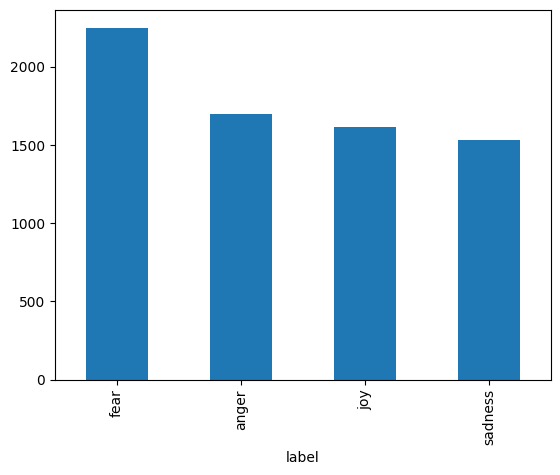

In [203]:
data['label'].value_counts().plot(kind='bar')

In [204]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x:x.sample(g.size().min()).reset_index(drop=True)))

C:\Users\sunny\AppData\Local\Temp\ipykernel_12692\1339254162.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x:x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

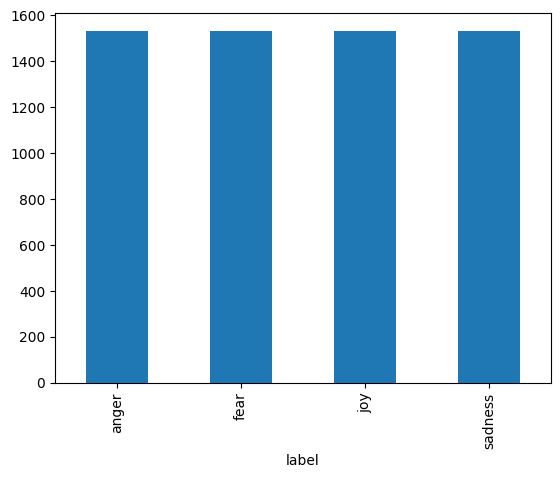

In [205]:
data['label'].value_counts().plot(kind='bar')

In [206]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [207]:
NUM_LABELS = 4

In [208]:
train_split, test_split =  train_test_split(data, train_size=0.8)
train_split, val_split = train_test_split(train_split, train_size=0.9)

In [209]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [210]:
train_df = pd.DataFrame({
    "label":train_split.label_int.values,
    "text": train_split.text_clean.values
})

test_df = pd.DataFrame({
    "label":test_split.label_int.values,
    "text": test_split.text_clean.values
})

In [211]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [212]:
dataset_dict  = datasets.DatasetDict({"train": train_df, "test": test_df})

In [213]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

Create Embeddings

In [214]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [215]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", max_length=128, truncation=True)

In [216]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [217]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [218]:
print(tokenized_datasets['train']['text'][0])

cri fear clear pathnbut voic seem silent chase ratnam indoor expect open doorna weak wise fool


In [219]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 17, 6752, 1819, 791, 2606, 180, 2438, 17, 2686, 556, 1589, 5548, 9751, 17, 5235, 8353, 7789, 1747, 433, 887, 597, 3570, 8484, 8956, 4, 3]


In [220]:
tokenizer.decode(5)

'<pad>'

In [221]:
print(tokenized_datasets['train']['token_type_ids'][0])

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]


In [222]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [223]:
small_train_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(100))

Fine tune our model

In [224]:
model = XLNetForSequenceClassification.from_pretrained("xlnet-base-cased", 
                                                       num_labels= NUM_LABELS, 
                                                       id2label={
                                                        0: 'anger',
                                                        1: 'fear',
                                                        2: 'joy',
                                                        3: 'sadness'
                                                        })

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [225]:
metric = evaluate.load('accuracy')

In [226]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [227]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)

In [228]:
trainer = Trainer(
    model=model, 
    args=training_args, 
    train_dataset = 
    small_train_dataset, 
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics)

In [229]:
trainer.train()

d:\Learning\python\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.379336,0.270000
2,No log,1.415543,0.220000
3,No log,1.388899,0.300000


d:\Learning\python\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\Learning\python\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\Learning\python\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=39, training_loss=1.3981343782865083, metrics={'train_runtime': 200.498, 'train_samples_per_second': 1.496, 'train_steps_per_second': 0.195, 'total_flos': 21366375321600.0, 'train_loss': 1.3981343782865083, 'epoch': 3.0})

Evaluate model

In [230]:
trainer.evaluate()

d:\Learning\python\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.3888992071151733,
 'eval_accuracy': 0.3,
 'eval_runtime': 12.6293,
 'eval_samples_per_second': 7.918,
 'eval_steps_per_second': 1.029,
 'epoch': 3.0}

In [232]:
model.save_pretrained("fine_tuned_model", safe_serialization=False)

In [ ]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

In [ ]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

Device set to use cpu


In [ ]:
rand_init = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_init])
answer = clf(val_split['text_clean'][rand_init], top_k=None)
print(answer)

shock awe place toddler manag get dinner
[{'label': 'sadness', 'score': 0.36068621277809143}, {'label': 'fear', 'score': 0.2841984033584595}, {'label': 'anger', 'score': 0.20339180529117584}, {'label': 'joy', 'score': 0.15172362327575684}]


C:\Users\sunny\AppData\Local\Temp\ipykernel_12692\251481843.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(val_split['text_clean'][rand_init])
C:\Users\sunny\AppData\Local\Temp\ipykernel_12692\251481843.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  answer = clf(val_split['text_clean'][rand_init], top_k=None)
